# Julián Serrano Chacón
# Mika Rodríguez Castro

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
import time # para medir tiempos de ejecución
import soundfile as sf     
from ipywidgets import interact
import sys
import random as rnd

# graficos en el notebook
%matplotlib inline

SRATE = 48000 # Sample rate, para todo el notebook

#### Ejercicio 1

Modificar el reproductor con control de volumen visto en clase (con slider de IpyWidgets) para que permita ajustar el volumen de cada canal por separado, a través de dos variables volL y volR (volumen del canal izquierdo y derecho).  
Si la muestra de entrada es mono, debe lanzarse una excepción e interrumpir la ejecución.  
Dado un chunk de audio estéreo almacenado en un array de NumPy bloque, el canal izquierdo puede obtenerse con bloque[:,0] y el derecho con bloque[:,1]

In [ ]:
#* Ej1
CHUNK = 2048
data, SRATE = sf.read('media/ex1.wav',dtype=np.float32)

#* si el audio es mono no se reproduce
try:
    if (len(data.shape)==1): 
        raise Exception("Mono not supported")
    
except Exception as e:
    print(e.args[0])
    sys.exit()
    

print(f"SRATE: {SRATE}   Format: {data.dtype}   Channels: {len(data.shape)}    Len: {data.shape[0]}")

#* volumen Izquierdo y volumen derecho
volL = 0.5
volR = 0.5

# contador de frames, global
current_frame = 0
def callback(outdata, frames, time, status):
    global current_frame       # para actualizarlo en cada callBack
    if status: print(status)

    # ojo, este print es muy lento... puede provocar underruns
    #print(f"\rNum Bloque: {current_frame//CHUNK}  frame: {current_frame}", end='') 

    # escribimos los samples correspondientes en el outdata que viene dado
    bloque = data[current_frame : current_frame+CHUNK]

    # * En vez de modificar el volumen en todos los canales directamente usando la instruccion anterior,
    # * se modifica cada uno de los canales por separado usando sus respectivos volumenes
    bloque[:,0] *= volL
    bloque[:,1] *= volR
        
    chunksize = bloque.shape[0]

    outdata[:chunksize] = bloque       
    
    if chunksize < frames: # ha terminado?
        print('fin')
        outdata[chunksize:] = 0 # rellenamos con 0's el resto de outdata
        raise sd.CallbackStop()

    # actualizamos frame con los frames procesados    
    current_frame += chunksize


# stream de salida con callBack
stream = sd.OutputStream(samplerate=SRATE, channels=len(data.shape),
    callback=callback, blocksize=CHUNK)
stream.start()


# controles de reproducción: volumen y parada

# * Hacemos un slider para volumen izquierdo y derecho

def LvolCtrl(Lv):
    global volL
    volL = Lv 
interact(LvolCtrl, Lv=(0.0,1.0,0.01))

def RvolCtrl(Rv):
    global volR
    volR = Rv  
interact(RvolCtrl, Rv=(0.0,1.0,0.01))


def pauseCtrl(pause):
    if pause==True:
        stream.stop()        
    else:
        stream.start()   
# lo interpreta como un checkbox
interact(pauseCtrl, pause=False)       



def stopCtrl(stop):
    if stop==True:
        stream.stop()
        stream.close()
interact(stopCtrl, stop=False)        


#### Ejercicio 2

Generar una muestra de ruido blanco de una duración dada en segundos. Para ello definiremos dos
funciones:

- noise1(dur): crea un array vacío con np.empty. El tamaño se calcula en función de dur
(1 segundo requiere SRATE muestras). A continuación rellena cada una de sus componentes
con valores aleatorios del intervalo [-1,1] utilizando la función básica random.random(), que
genera valores individuales.

- noise2(dur): genera directamente la señal en un array de tamaño adecuado utilizando la
función de NumPy random.random o random.uniform, que delegan la generación del array
completo directamente en NumPy.

Dibujar la señal obtenida con Matplotlib. Para ver samples aislados puede generarse una muestra
de corta duración o bien dibujar solo una parte de la señal (haciendo slicing de arrays). Asegurarse
de que los valores generados están en el intervalo [-1,1].
Comparar el tiempo de ejecución de ambos métodos generando señales de suficiente duración. Para
medir el tiempo de ejecución de un fragmento de código puede hacerse:

    start = time.time()
    # código ...
    print(f'time: {time.time() - start}')

¿Qué versión de noise es más eficiente?

__La que usa la funcion de numpy__

Generar una señal de ruido de 1 segundo de duración y reproducirla.

In [ ]:
#* Ej2
# * Declaramos data
data = 0

# * Definimos una primera funcion que genera y guarda valores aleatorios del -1 al 1 en data usando el
# * random de python
def noise1(dur):
    global data 
    data = np.empty([SRATE * dur])

    for i in range(0, SRATE * dur):
        data[i] = (rnd.random() * 2) - 1

# * Definimos una segunda que hace lo mismo pero en vez de usar el random de python usa el uniform de
# * numpy que permite utilizar la distribucion uniforme para generar x valores pseudoaleatorios y guardarlos 
# * en un array
def noise2(dur):
    global data
    data = np.random.uniform(-1.0, 1.0, SRATE * dur)

# * registramos el tiempo que tarda en ejecutarse
start = time.time()
noise1(1)
print(f'time: {time.time() - start}')

# * pintamos la grafica creando una figura nueva, la titulamos para diferenciarla, le damos los puntos y la
# * imprimimos
plt.figure(1)
plt.title("noise1")
plt.plot(data)
plt.show()

# * lo mismo para la otra funcion
start = time.time()
noise2(1)
print(f'time: {time.time() - start}')

plt.figure(2)
plt.title("noise2")
plt.plot(data)
plt.show()

# * escuchamos solo la segunda
sd.play(data, SRATE)


#### Ejercicio 3
. Generar una onda sinusoidal de 1 Hz con frecuencia de muestreo SRATE y 1 segundo de duración, y
dibujarla. Debe tener el siguiente aspecto:  
  
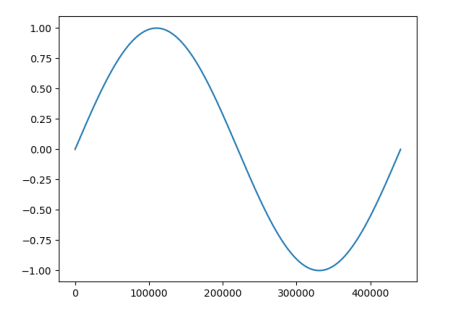 
  
Como antes, crearemos un array de NumPy para almacenar las muestras.  
En este caso será útil la función np.arange(N) para generar el array de soporte y aplicar la función np.sin para calcular el
valor de las muestras.  
Nótese que el instante t = 1 seg. corresponde al argumento 2π para la función np.sin.  




A continuación, obtener una señal de 2 Hz y 1 segundo de duración, y otra de 3 Hz y 2 segundos
de duración. Dibujar los resultados.  
Generar varias señales de 1 segundo de duración con diversas frecuencias (110 Hz, 220 Hz, . . . ), hacer una suma ponderada y reproducirlas.  
Prueba con frecuencias muy agudas y muy graves para determinar cuáles son las frecuencia mínima y máxima que puedes escuchar.  
Utiliza niveles moderados de volumen para no dañar tus oídos.  

In [ ]:
#* Ej3
data = np.arange(0,2*np.pi,2*np.pi/SRATE,dtype=float)
data = np.sin(data)

plt.figure(1)
plt.title("onda sinusoidal")
plt.plot(data)
plt.show()

data = np.arange(0,4*np.pi,2*np.pi/SRATE,dtype=float)
data = np.sin(data)

plt.figure(2)
plt.title("onda sinusoidal 2Hz")
plt.plot(data)
plt.show()

data = np.arange(0,6*np.pi,2*np.pi/SRATE,dtype=float)
data *= 2
data = np.sin(data)

plt.figure(3)
plt.title("onda sinusoidal 3Hz")
plt.plot(data)
plt.show()

data = np.arange(0,220*np.pi,2*np.pi/SRATE,dtype=float)
data *= 5
data = np.sin(data)

plt.figure(4)
plt.title("onda sinusoidal reproducido (pedillop)")
plt.plot(data)
plt.show()


sd.play(data,SRATE)

#### Ejercicio 4
Vamos a generalizar el ejercicio anterior implementando una función osc(freq,dur=1,amp=1, phase=0) que devuelva una señal sinusoidal de frecuencia freq, duración dur segundos, amplitud amp y fase phase (en radianes).  
Por ejemplo, osc(2,1,1,np.pi/2) tendrá esta forma:    
  
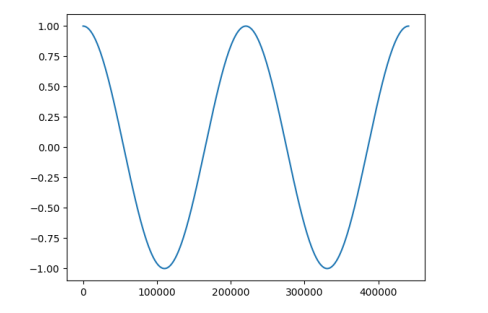    
  
Dibujar varias señales con distintos parámetros.  
Prueba con diferentes valores de fase y escucha las diferencias.  
Probar también con diferentes valores para SRATE.



In [ ]:
data = 0

#* SRATE = 250000
def osc(freq,dur=1,amp=1, phase=0):
    global data
    data = np.arange(phase,2*freq*np.pi + amp,2*amp*np.pi/SRATE,dtype=float)
    data = np.sin(data)
    data *= dur


osc(2,1,1,np.pi/2)
plt.figure(1)
plt.title("onda sinusoidal 1 (reproduccion)")
plt.plot(data)
plt.show()

osc(110,3,1,np.pi/2)
plt.figure(2)
plt.title("onda sinusoidal 2")
plt.plot(data)
plt.show()

sd.play(data,SRATE)

